# 05 — Machine Learning: huấn luyện tháng 4–8, kiểm tra trên tháng 9–10 (năm 2022)

**Cách kiểm tra (out-of-time):** mô hình chỉ được học các chuyến bay có **ngày bay từ 04 → 08/2022**, rồi dự đoán
giá vé cho các chuyến bay **tháng 09 và 10/2022** mà nó chưa từng thấy. Nếu sai số nhỏ, mô hình đủ tin cậy để
dùng cho các tháng / năm tiếp theo (notebook 06).

- Dữ liệu: mẫu ngẫu nhiên **5%** của Silver (≈ 4 triệu vé) — giới hạn RAM 16 GB của máy.
- Chỉ số đầu vào: lấy từ kết quả **tương quan** ở notebook 04 (`feature_selection.json`).
- So sánh **5 mô hình** (Spark MLlib): Baseline (trung vị theo tuyến × thời điểm đặt), Linear Regression,
  Decision Tree, Random Forest, Gradient-Boosted Trees.
- Thêm một thí nghiệm: **chỉ dùng dữ liệu chuyến bay** vs **có tích hợp nguồn ngoài** → giá trị của việc tích hợp.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))
from common import *
from viz import *
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, Imputer
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor

spark = get_spark("05-ml")
sel = json.load(open(f"{GOLD}/feature_selection.json", encoding="utf-8"))
NUM, CAT = sel["numeric"], sel["categorical"]
print("Biến số:", NUM)
print("Biến phân loại:", CAT)

Biến số: ['totalTravelDistance', 'duration_min', 'basic_economy', 'multi_airline', 'num_stops', 'non_stop', 'cross_region', 'cabin_level', 'week_of_year', 'cpi_airfare', 'elapsedDays', 'jet_fuel_usd_gal', 'inflation_yoy', 'seatsRemaining', 'cpi_all', 'lat_diff', 'is_weekend', 'origin_precip_mm', 'days_before', 'dest_precip_mm', 'origin_wind_max', 'is_holiday']
Biến phân loại: ['route', 'airline_code', 'startingAirport', 'destinationAirport', 'origin_region', 'dest_region']


In [2]:
TRAIN_MONTHS = ["2022-04", "2022-05", "2022-06", "2022-07", "2022-08"]
TEST_MONTHS = ["2022-09", "2022-10"]

data = (spark.read.parquet(SILVER)
        .filter(F.col("flight_month").isin(TRAIN_MONTHS + TEST_MONTHS))
        .sample(fraction=ML_FRACTION, seed=SEED)
        .withColumn("label", F.log("totalFare"))
        .select("label", "totalFare", "flightDate", "flight_month", "days_before", "booking_window", "route",
                *set(NUM + CAT) - {"days_before", "route"}))
train = data.filter(F.col("flight_month").isin(TRAIN_MONTHS)).cache()
test = data.filter(F.col("flight_month").isin(TEST_MONTHS)).cache()
n_train, n_test = train.count(), test.count()
print(f"Train (bay 04–08/2022): {n_train:,} vé | Test (bay 09–10/2022): {n_test:,} vé")

Train (bay 04–08/2022): 2,565,747 vé | Test (bay 09–10/2022): 1,415,403 vé


## Kiểm tra phạm vi giá trị (bổ sung cho bước chọn chỉ số bằng tương quan)

Khi dự đoán **tương lai** (tháng 9–10), một chỉ số chỉ hữu ích nếu giá trị của nó ở tháng 9–10 đã từng xuất hiện
trong dữ liệu huấn luyện. Các chỉ số chỉ "đánh dấu thời gian" như tuần trong năm hay CPI chung (tăng đều theo tháng)
có giá trị tháng 9–10 **nằm ngoài** khoảng của tháng 4–8 → mô hình cây không ngoại suy được và sẽ học sai.
Quy tắc: loại chỉ số nếu **> 50%** giá trị ở tập kiểm tra nằm ngoài [min, max] của tập huấn luyện.

In [3]:
rng = train.select(*[F.min(c).alias(f"{c}__min") for c in NUM], *[F.max(c).alias(f"{c}__max") for c in NUM]).first()
out_share = test.select(*[F.avg(((F.col(c) < rng[f"{c}__min"]) | (F.col(c) > rng[f"{c}__max"])).cast("double")).alias(c)
                          for c in NUM]).first().asDict()
range_check = pd.DataFrame({"min_train": [rng[f"{c}__min"] for c in NUM], "max_train": [rng[f"{c}__max"] for c in NUM],
                            "% test ngoài khoảng": [round((out_share[c] or 0) * 100, 1) for c in NUM]}, index=NUM)
range_check.to_csv(f"{EXPORTS}/05_range_check.csv")
OUT_OF_RANGE = [c for c in NUM if (out_share[c] or 0) > 0.5]
NUM = [c for c in NUM if c not in OUT_OF_RANGE]
print("Loại vì ngoài phạm vi huấn luyện:", OUT_OF_RANGE)
print("Còn lại", len(NUM), "biến số:", NUM)
range_check.sort_values("% test ngoài khoảng", ascending=False).head(10)

Loại vì ngoài phạm vi huấn luyện: ['week_of_year', 'inflation_yoy', 'cpi_all']
Còn lại 19 biến số: ['totalTravelDistance', 'duration_min', 'basic_economy', 'multi_airline', 'num_stops', 'non_stop', 'cross_region', 'cabin_level', 'cpi_airfare', 'elapsedDays', 'jet_fuel_usd_gal', 'seatsRemaining', 'lat_diff', 'is_weekend', 'origin_precip_mm', 'days_before', 'dest_precip_mm', 'origin_wind_max', 'is_holiday']


,min_train,max_train,% test ngoài khoảng
week_of_year,15.000000,35.000000,91.9
inflation_yoy,8.258629,9.059758,50.8
cpi_all,289.109000,296.311000,50.8
origin_precip_mm,0.000000,101.100000,0.3
origin_wind_max,7.400000,47.200000,0.3
dest_precip_mm,0.000000,101.100000,0.3
non_stop,0.000000,1.000000,0.0
num_stops,0.000000,4.000000,0.0
multi_airline,0.000000,1.000000,0.0
basic_economy,0.000000,1.000000,0.0


## Pipeline đặc trưng
- Biến phân loại → `StringIndexer` (cây quyết định) hoặc thêm `OneHotEncoder` (hồi quy tuyến tính).
- Giá trị thiếu (khoảng cách bay, thời tiết...) → `Imputer` (trung vị).
- Học trên **log(giá vé)** vì giá lệch phải mạnh; khi đánh giá đổi lại về USD.

In [4]:
def feature_stages(num, cat, linear=False):
    imputed = [f"{c}_imp" for c in num]
    stages = [Imputer(inputCols=num, outputCols=imputed, strategy="median")]
    stages += [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat]
    if linear:
        stages += [OneHotEncoder(inputCols=[f"{c}_idx" for c in cat], outputCols=[f"{c}_ohe" for c in cat])]
        stages += [VectorAssembler(inputCols=imputed, outputCol="num_vec"),
                   StandardScaler(inputCol="num_vec", outputCol="num_scaled", withMean=True),
                   VectorAssembler(inputCols=["num_scaled"] + [f"{c}_ohe" for c in cat], outputCol="features")]
    else:
        stages += [VectorAssembler(inputCols=imputed + [f"{c}_idx" for c in cat], outputCol="features")]
    return stages

def evaluate(pred, name, seconds):
    p = pred.withColumn("pred_fare", F.exp("prediction"))
    m = p.select(
        F.sqrt(F.avg((F.col("pred_fare") - F.col("totalFare")) ** 2)).alias("RMSE"),
        F.avg(F.abs(F.col("pred_fare") - F.col("totalFare"))).alias("MAE"),
        (F.avg(F.abs(F.col("pred_fare") - F.col("totalFare")) / F.col("totalFare")) * 100).alias("MAPE_%"),
        (1 - F.sum((F.col("pred_fare") - F.col("totalFare")) ** 2)
             / F.sum((F.col("totalFare") - F.lit(test_mean)) ** 2)).alias("R2"),
    ).first().asDict()
    return {"model": name, **{k: round(v, 4) for k, v in m.items()}, "train_seconds": round(seconds, 1)}

test_mean = test.agg(F.avg("totalFare")).first()[0]
MAX_BINS = 300   # ≥ số tuyến (≈ 235) để cây quyết định dùng được biến 'route'

## Huấn luyện và so sánh các mô hình

In [5]:
results, preds, models = [], {}, {}

# 0) Baseline: trung vị log(giá) theo tuyến × nhóm thời điểm đặt, học trên tập train
t0 = time.time()
base = train.groupBy("route", "booking_window").agg(F.percentile_approx("label", 0.5).alias("prediction"))
fallback = train.agg(F.percentile_approx("label", 0.5)).first()[0]
pred_base = test.join(base, ["route", "booking_window"], "left").fillna({"prediction": fallback})
results.append(evaluate(pred_base, "Baseline (trung vị tuyến × thời điểm đặt)", time.time() - t0))
preds["Baseline"] = pred_base

algos = {
    "Linear Regression": (LinearRegression(featuresCol="features", labelCol="label", regParam=0.01, elasticNetParam=0.0, maxIter=50), True),
    "Decision Tree": (DecisionTreeRegressor(featuresCol="features", labelCol="label", maxDepth=12, maxBins=MAX_BINS, seed=SEED), False),
    # Tham số vừa với RAM 16 GB của máy (Spark local): rừng 30 cây sâu 10, GBT 60 vòng sâu 6
    "Random Forest": (RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=30, maxDepth=10,
                                            maxBins=MAX_BINS, subsamplingRate=0.4, featureSubsetStrategy="onethird",
                                            cacheNodeIds=True, checkpointInterval=10, seed=SEED), False),
    "Gradient-Boosted Trees": (GBTRegressor(featuresCol="features", labelCol="label", maxIter=60, maxDepth=6,
                                            stepSize=0.2, maxBins=MAX_BINS, subsamplingRate=0.6,
                                            cacheNodeIds=True, checkpointInterval=10, seed=SEED), False),
}
spark.sparkContext.setCheckpointDir(f"{DATA_DIR}/spark-tmp/checkpoints")
for name, (algo, linear) in algos.items():
    t0 = time.time()
    model = Pipeline(stages=feature_stages(NUM, CAT, linear) + [algo]).fit(train)
    secs = time.time() - t0
    pred = model.transform(test)            # không cache để tiết kiệm RAM
    results.append(evaluate(pred, name, secs))
    preds[name], models[name] = pred, model
    print(results[-1], flush=True)

res = pd.DataFrame(results).set_index("model")
res.to_csv(f"{EXPORTS}/05_model_comparison.csv")
res

{'model': 'Linear Regression', 'RMSE': 125.0742, 'MAE': 83.2839, 'MAPE_%': 32.4065, 'R2': 0.5102, 'train_seconds': 23.3}


{'model': 'Decision Tree', 'RMSE': 105.3573, 'MAE': 70.0368, 'MAPE_%': 28.3898, 'R2': 0.6524, 'train_seconds': 30.5}


{'model': 'Random Forest', 'RMSE': 108.5992, 'MAE': 71.628, 'MAPE_%': 29.9238, 'R2': 0.6307, 'train_seconds': 77.6}


{'model': 'Gradient-Boosted Trees', 'RMSE': 103.5488, 'MAE': 67.5319, 'MAPE_%': 25.681, 'R2': 0.6643, 'train_seconds': 292.3}


,RMSE,MAE,MAPE_%,R2,train_seconds
model,,,,,
Baseline (trung vị tuyến × thời điểm đặt),167.1612,122.0138,60.2783,0.1251,1.7
Linear Regression,125.0742,83.2839,32.4065,0.5102,23.3
Decision Tree,105.3573,70.0368,28.3898,0.6524,30.5
Random Forest,108.5992,71.6280,29.9238,0.6307,77.6
Gradient-Boosted Trees,103.5488,67.5319,25.6810,0.6643,292.3


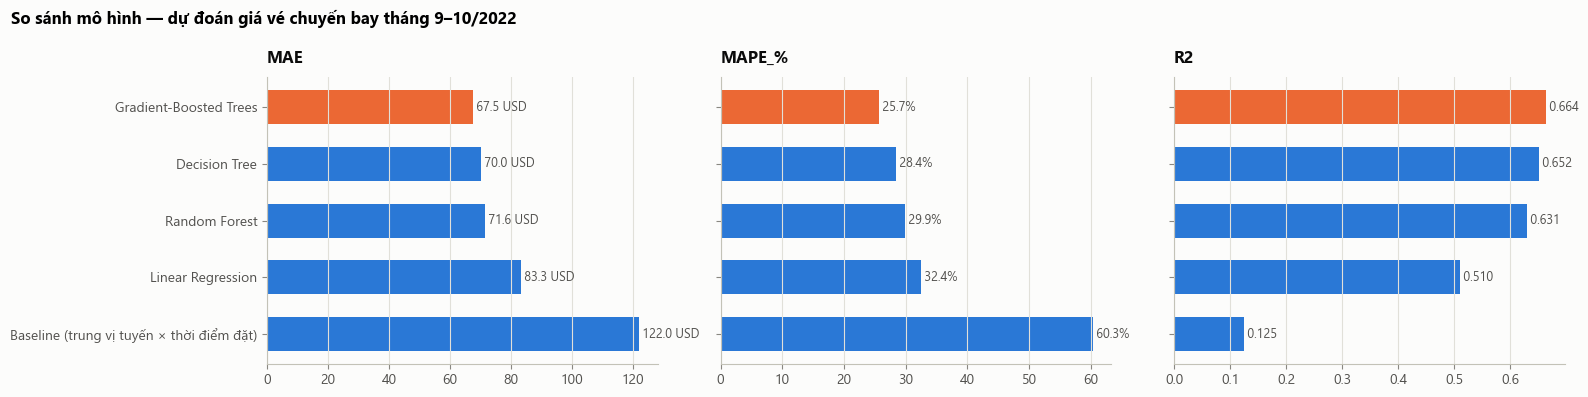

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
order = res.sort_values("MAE", ascending=False)
for ax, metric, fmt in zip(axes, ["MAE", "MAPE_%", "R2"], ["{:.1f} USD", "{:.1f}%", "{:.3f}"]):
    colors = [SERIES[1] if m == res[metric].idxmin() and metric != "R2" or m == res["R2"].idxmax() and metric == "R2"
              else SERIES[0] for m in order.index]
    ax.barh(order.index, order[metric], color=colors, height=0.6)
    for y, v in enumerate(order[metric]):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=9, color=INK_2)
    ax.set_title(metric); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    if ax is not axes[0]: ax.set_yticklabels([])
plt.suptitle("So sánh mô hình — dự đoán giá vé chuyến bay tháng 9–10/2022", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_05_model_comparison.png", dpi=150); plt.show()

## Giá trị của việc tích hợp dữ liệu
Huấn luyện lại mô hình tốt nhất **chỉ với các chỉ số có sẵn trong dữ liệu chuyến bay**, rồi so với bản có thêm
ngày lễ, thời tiết, nhiên liệu, CPI, thông tin sân bay.

In [7]:
best_name = res.drop(index=res.index[0])["MAE"].idxmin()
EXTERNAL_COLS = {"is_holiday", "holiday_window", "days_to_holiday", "jet_fuel_usd_gal", "fuel_7d_change", "cpi_all",
                 "cpi_airfare", "inflation_yoy", "airfare_yoy", "cross_region", "lat_diff", "origin_region", "dest_region"}
EXTERNAL_COLS |= {c for c in NUM if c.startswith(("origin_", "dest_"))}
num_only = [c for c in NUM if c not in EXTERNAL_COLS]
cat_only = [c for c in CAT if c not in EXTERNAL_COLS]
algo, linear = algos[best_name]
t0 = time.time()
m_only = Pipeline(stages=feature_stages(num_only, cat_only, linear) + [algo.copy()]).fit(train)
r_only = evaluate(m_only.transform(test), f"{best_name} — chỉ dữ liệu chuyến bay", time.time() - t0)
ablation = pd.DataFrame([r_only, {**results[list(res.index).index(best_name)], "model": f"{best_name} — có tích hợp nguồn ngoài"}]).set_index("model")
ablation.to_csv(f"{EXPORTS}/05_integration_ablation.csv")
print("Bỏ nguồn ngoài:", sorted((set(NUM) | set(CAT)) - set(num_only) - set(cat_only)))
ablation

Bỏ nguồn ngoài: ['cpi_airfare', 'cross_region', 'dest_precip_mm', 'dest_region', 'is_holiday', 'jet_fuel_usd_gal', 'lat_diff', 'origin_precip_mm', 'origin_region', 'origin_wind_max']


,RMSE,MAE,MAPE_%,R2,train_seconds
model,,,,,
Gradient-Boosted Trees — chỉ dữ liệu chuyến bay,115.9550,80.2737,33.3079,0.5790,261.8
Gradient-Boosted Trees — có tích hợp nguồn ngoài,103.5488,67.5319,25.6810,0.6643,292.3


## Mức độ quan trọng của chỉ số (mô hình cây tốt nhất)

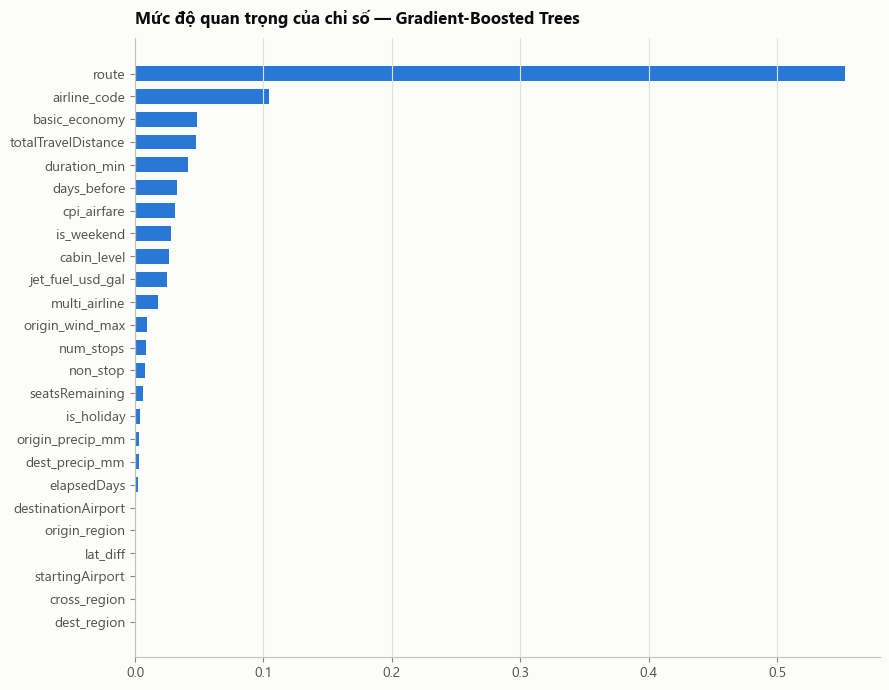

In [8]:
tree_name = best_name if best_name != "Linear Regression" else "Gradient-Boosted Trees"
fm = models[tree_name].stages[-1]
feat_names = [f"{c}" for c in NUM] + CAT
imp = pd.Series(fm.featureImportances.toArray(), index=feat_names).sort_values()
imp.to_csv(f"{EXPORTS}/05_feature_importance.csv", header=["importance"])
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp.index, imp.values, color=SERIES[0], height=0.65)
ax.set_title(f"Mức độ quan trọng của chỉ số — {tree_name}"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_05_feature_importance.png", dpi=150); plt.show()

## Dự đoán theo ngày: thực tế vs dự đoán cho tháng 9–10/2022

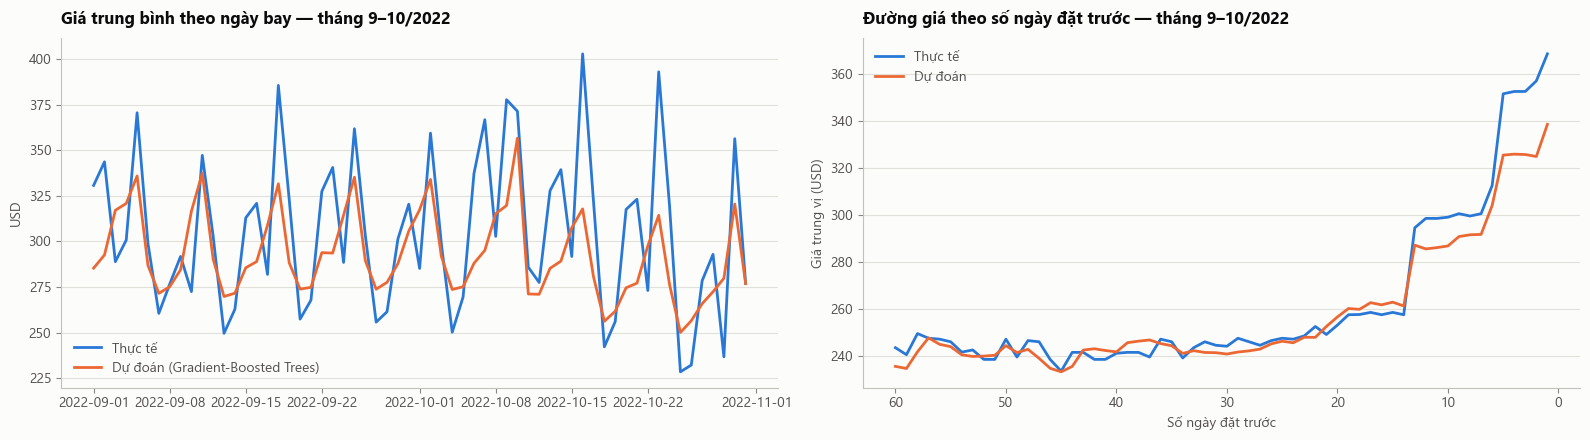

In [9]:
best = preds[best_name].withColumn("pred_fare", F.exp("prediction"))
by_day = (best.groupBy("flightDate").agg(F.avg("totalFare").alias("thuc_te"), F.avg("pred_fare").alias("du_doan"),
                                         F.count("*").alias("n")).orderBy("flightDate").toPandas())
by_db = (best.groupBy("days_before").agg(F.percentile_approx("totalFare", 0.5).alias("thuc_te"),
                                         F.percentile_approx("pred_fare", 0.5).alias("du_doan")).orderBy("days_before").toPandas())
by_day.to_csv(f"{EXPORTS}/05_test_by_flight_date.csv", index=False)
by_db.to_csv(f"{EXPORTS}/05_test_by_days_before.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(by_day.flightDate, by_day.thuc_te, color=SERIES[0], label="Thực tế")
axes[0].plot(by_day.flightDate, by_day.du_doan, color=SERIES[1], label=f"Dự đoán ({best_name})")
axes[0].set_title("Giá trung bình theo ngày bay — tháng 9–10/2022"); axes[0].set_ylabel("USD"); axes[0].legend()
axes[1].plot(by_db.days_before, by_db.thuc_te, color=SERIES[0], label="Thực tế")
axes[1].plot(by_db.days_before, by_db.du_doan, color=SERIES[1], label="Dự đoán")
axes[1].invert_xaxis(); axes[1].set_xlabel("Số ngày đặt trước"); axes[1].set_ylabel("Giá trung vị (USD)")
axes[1].set_title("Đường giá theo số ngày đặt trước — tháng 9–10/2022"); axes[1].legend()
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_05_actual_vs_pred.png", dpi=150); plt.show()

In [10]:
# Sai số theo nhóm thời điểm đặt vé
err_window = (best.groupBy("booking_window")
              .agg(F.count("*").alias("n"), F.avg("totalFare").alias("gia_thuc_te_tb"), F.avg("pred_fare").alias("gia_du_doan_tb"),
                   (F.avg(F.abs(F.col("pred_fare") - F.col("totalFare")) / F.col("totalFare")) * 100).alias("MAPE_%"))
              .orderBy("booking_window").toPandas().round(2))
err_window.to_csv(f"{EXPORTS}/05_error_by_booking_window.csv", index=False)
err_window

,booking_window,n,gia_thuc_te_tb,gia_du_doan_tb,MAPE_%
0,1. Rất gấp (1-7 ngày),149846,367.07,344.59,20.72
1,2. Gấp (8-30 ngày),617031,304.67,295.71,26.22
2,3. Sớm (31-60 ngày),648526,284.83,277.25,26.31


## Lưu mô hình tốt nhất (huấn luyện lại trên toàn bộ tháng 4–10) để dùng cho dự báo ở notebook 06

In [11]:
train.unpersist(); test.unpersist()
full = data.cache()
algo, linear = algos[best_name]
final = Pipeline(stages=feature_stages(NUM, CAT, linear) + [algo.copy()]).fit(full)
final.write().overwrite().save(f"{DATA_DIR}/models/best_model")
json.dump({"best_model": best_name, "numeric": NUM, "categorical": CAT,
           "test_metrics": res.loc[best_name].to_dict()},
          open(f"{GOLD}/best_model.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print("Đã lưu mô hình:", best_name)

Đã lưu mô hình: Gradient-Boosted Trees
